In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os

In [31]:
directory_path = '../Data/Domain Data/Original data (as is)/PhishLab Ukraine-related-Domains'

domain_frequency_per_day = {}
# domain_with_date = {}

for filename in os.listdir(directory_path):
    filepath = os.path.join(directory_path, filename)
    # print(filename[16:26])
    if os.path.isfile(filepath):
        with open(filepath, 'r') as file:
            content = file.read()
            # Process the content of the file
            # print(content)
            flag = 'Y).'
            # print(content.index(flag))
            # print((content[322+len(flag)+1:].split('\n')))
            # for i in content[322+len(flag)+1:].split('\n'):
            #     domain_with_date[i] = filename[16:26]

            # print(filename[16:26])
            # break
            domain_frequency_per_day[filename[16:26]] = len(content[322+len(flag)+1:].split('\n'))


# domain_with_date
    

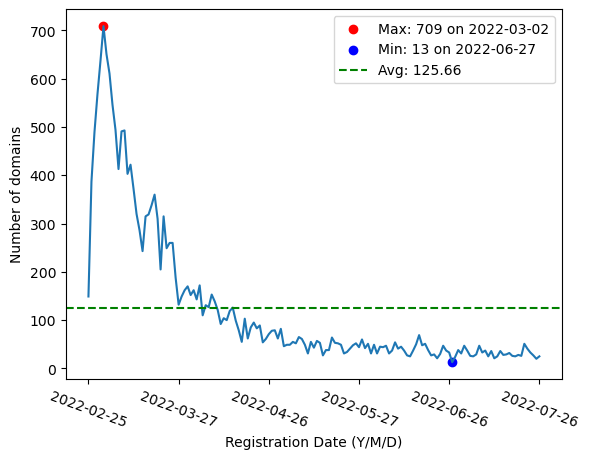

In [32]:
import matplotlib.pyplot as plt

# Data for plotting
dates = list(domain_frequency_per_day.keys())
frequencies = list(domain_frequency_per_day.values())

# Plot the data
plt.plot(dates, frequencies)

# Label the axes
plt.xlabel('Registration Date (Y/M/D)')
plt.ylabel('Number of domains')

# Set x-ticks at intervals of 30
xtick_positions = list(range(0, len(dates), 30))
xtick_labels = [dates[i] for i in xtick_positions]
plt.xticks(xtick_positions, xtick_labels, rotation=-20)

# Highlight the max point
max_value = max(frequencies)
max_idx = frequencies.index(max_value)
plt.scatter(dates[max_idx], max_value, color='red', label=f'Max: {max_value} on {dates[max_idx]}')

# Highlight the min point
min_value = min(frequencies)
min_idx = frequencies.index(min_value)
plt.scatter(dates[min_idx], min_value, color='blue', label=f'Min: {min_value} on {dates[min_idx]}')

# Plot average line
avg = sum(frequencies) / len(frequencies)
plt.axhline(y=avg, color='green', linestyle='--', label=f'Avg: {round(avg, 2)}')

# Title
# plt.title('Per-day Domain registration count from Feb 25 - Jul 26, 2022')

# Show legend
plt.legend()

# Show the plot
plt.show()


In [33]:
df = pd.read_csv('../Data/Clusters/All_5_Clustering_Algo_Result_10-30-2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2118 entries, 0 to 2117
Data columns (total 55 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Landing_Page_Size_In_KB                      2118 non-null   float64
 1   Same Landing Domain                          2118 non-null   int64  
 2   Has Bank Related Keywords                    2118 non-null   int64  
 3   Has Crypto Related Keywords                  2118 non-null   int64  
 4   Has Card Related Keywords                    2118 non-null   int64  
 5   Unique_Internal_Page_Link_Cnt                2118 non-null   int64  
 6   Unique_External_Page_Link_Cnt                2118 non-null   int64  
 7   Avg_External_Links_Len                       2118 non-null   float64
 8   Stdv_External_Links_Len                      2118 non-null   float64
 9   Ratio_Shortened_URL_And_External_Links       2118 non-null   float64
 10  

In [34]:
df['Majority Voting Label']

0       0
1       0
2       0
3       0
4       2
       ..
2113    0
2114    0
2115    0
2116    0
2117    0
Name: Majority Voting Label, Length: 2118, dtype: int64

In [35]:
df.head()

,Landing_Page_Size_In_KB,Same Landing Domain,Has Bank Related Keywords,Has Crypto Related Keywords,Has Card Related Keywords,Unique_Internal_Page_Link_Cnt,Unique_External_Page_Link_Cnt,Avg_External_Links_Len,Stdv_External_Links_Len,Ratio_Shortened_URL_And_External_Links,...,IPQS Phishing,IPQS Suspicious,IPQS Adult,IPQS Risk Score,VT Malicious,VT Suspicious,VT Harmless,VT NoData Available,Domain Creation Date,External Links
0,86.53,1,0,0,0,7,5,50.80,10.26,0.0,...,False,False,False,0,0,0,1,1,2022-03-10,['https://www.facebook.com/1001-Minutes-for-Uk...
1,123.73,1,0,0,0,15,2,75.50,32.50,0.0,...,False,True,False,55,0,0,1,1,2022-06-06,['https://padlet.com/linda22/uk9hqc1ftu82xcwy'...
2,96.91,1,0,0,0,2,3,43.00,5.10,0.0,...,False,False,False,0,1,0,0,1,2022-04-03,['https://www.facebook.com/UneViolettePourlUkr...
3,1170.81,1,0,0,0,1,14,45.43,24.74,0.0,...,False,True,False,55,0,0,1,1,2022-06-01,"['https://www.instagram.com/36daysoftype', 'ht..."
4,47.44,1,0,0,0,25,19,29.11,17.09,0.0,...,True,True,False,91,0,0,1,1,2022-03-22,"['https://www.facebook.com/4myukraine', 'https..."


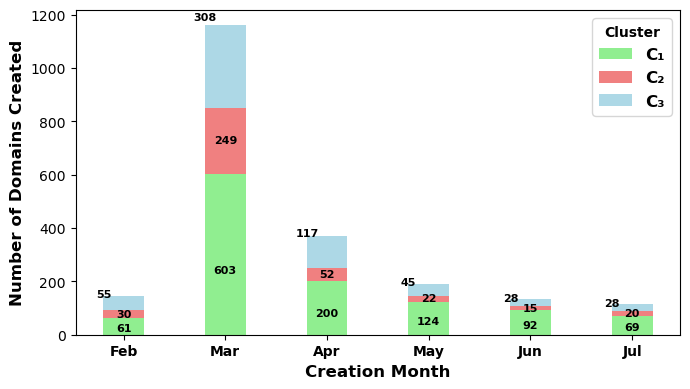

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_domain_creation_monthly_stacked_bar_with_counts(df):
    
    # Ensure 'Domain Creation Date' is in datetime format
    df['Domain Creation Date'] = pd.to_datetime(df['Domain Creation Date'])

    # Extract month from 'Domain Creation Date'
    df['Creation Month'] = df['Domain Creation Date'].dt.to_period('M')

    # Group by month and label, then count domains
    monthly_counts = df.groupby(['Creation Month', 'Majority Voting Label']).size().unstack(fill_value=0)

    # Sort the index (months)
    monthly_counts = monthly_counts.sort_index()

    # Define colors for the bars
    colors = ['lightgreen', 'lightcoral', 'lightblue']
    labels = ['C₁', 'C₂', 'C₃']  # Corresponding labels for the legend

    # Set the width of the bars
    bar_width = 0.4  # Default is 0.8; try a smaller value

    # Calculate the positions for the bars
    num_months = len(monthly_counts.index)
    x = range(num_months)

    # Plot the stacked bar chart
    fig, ax = plt.subplots(figsize=(7, 4))  # Reduced y-dimension (height)

    bottom = [0] * num_months
    for label_idx, label_col in enumerate(monthly_counts.columns):
        counts = monthly_counts[label_col].values
        bars = ax.bar(x, counts, bar_width, bottom=bottom, color=colors[label_idx], label=labels[label_idx])
        for rect_idx, rect in enumerate(bars):
            height = rect.get_height()
            if height > 2:  # Only add text if height is above this threshold
                x_pos = rect.get_x() + rect.get_width() / 2
                y_pos = 0
                if label_idx == 0:
                    y_pos = rect.get_y() + 0.4 * height
                elif label_idx == 1:
                    y_pos = rect.get_y() + height / 2
                elif label_idx == 2:
                    y_pos = rect.get_y() + height + 0.1 * height
                    x_pos = rect.get_x() + rect.get_width() / 100  # Shift text to the left

                ax.text(x_pos, y_pos, f'{int(height)}',
                        ha='center', va='center', color='black', fontsize=8, fontweight='bold')
        bottom = [b + c for b, c in zip(bottom, counts)]

    # Format x-axis (months)
    ax.set_xlabel('Creation Month', fontweight='bold', fontsize=12)
    ax.set_ylabel('Number of Domains Created', fontweight='bold', fontsize=12)
    # ax.set_title('Stacked Bar Chart of Monthly Domain Creation Counts by Cluster Label')

    # Set x-axis tick positions and labels
    ax.set_xticks(x)
    ax.set_xticklabels([month.strftime('%b') for month in monthly_counts.index], ha='center', fontweight='bold', fontsize=10)

    # Add a legend with bold text
    legend = ax.legend(title='Cluster', fontsize=12)
    if legend:
        for text in legend.get_texts():
            text.set_fontweight('bold')
        if legend.get_title():
            legend.get_title().set_fontweight('bold')

    plt.tight_layout()
    plt.show()


plot_domain_creation_monthly_stacked_bar_with_counts(df)

In [37]:


print(df['Domain Creation Date'].min())
print(df['Domain Creation Date'].max())

2022-02-26 00:00:00
2022-07-26 00:00:00


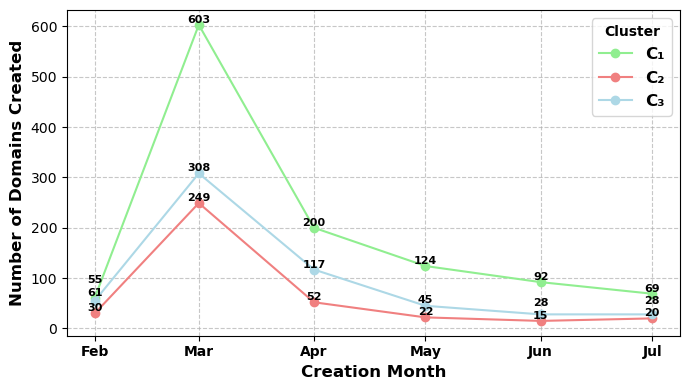

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from collections import defaultdict

def plot_cluster_frequency_with_counts(df):
    """
    Plots the frequency of each cluster across months, with website counts highlighted,
    and adjusts text label positions to avoid overlap.

    Args:
        df (pd.DataFrame): DataFrame with 'Domain Name', 'Domain Creation Date', and
                           'Majority Voting Label' columns.
    """
    # Ensure 'Domain Creation Date' is in datetime format
    df['Domain Creation Date'] = pd.to_datetime(df['Domain Creation Date'])

    # Extract month from 'Domain Creation Date'
    df['Creation Month'] = df['Domain Creation Date'].dt.to_period('M')

    # Group by month and cluster, then count domains
    monthly_cluster_counts = df.groupby(['Creation Month', 'Majority Voting Label']).size().unstack(fill_value=0)

    # Sort the index (months)
    monthly_cluster_counts = monthly_cluster_counts.sort_index()

    # Define colors and labels
    colors = ['lightgreen', 'lightcoral', 'lightblue']
    labels = ['C₁', 'C₂', 'C₃']

    # Create the plot
    fig, ax = plt.subplots(figsize=(7, 4))  # Adjust figure size as needed

    # Store label positions to check for overlap
    label_positions = defaultdict(list)

    # Plot each cluster's frequency
    for i, cluster_label in enumerate(monthly_cluster_counts.columns):
        cluster_data = monthly_cluster_counts[cluster_label]
        ax.plot(cluster_data.index.to_timestamp(), cluster_data.values,
                color=colors[i], label=labels[i], marker='o', linestyle='-')

        # Add text labels for the counts, avoiding overlap
        for x, y in zip(cluster_data.index.to_timestamp(), cluster_data.values):
            text_y = y
            
            # Check for overlap with existing labels in the same month
            month_key = x.to_period('M')  # Use month as the key
            
            overlap = False
            for existing_y in label_positions[month_key]:
                if abs(text_y - existing_y) < 30:  # Adjust the threshold as needed (e.g., 5)
                    overlap = True
                    text_y = existing_y + 25  # Adjust y-position to avoid overlap
                    break
            
            if not overlap:
                label_positions[month_key].append(text_y)  # Store the adjusted position

            ax.text(x, text_y, f'{int(y)}', ha='center', va='bottom', fontsize=8,
                    color='black', fontweight='bold')

    # Format the x-axis to show months
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    plt.xticks(rotation=0, ha='center', fontsize=10, fontweight='bold')

    # Set labels and title
    ax.set_xlabel('Creation Month', fontweight='bold', fontsize=12)
    ax.set_ylabel('Number of Domains Created', fontweight='bold', fontsize=12)
    # ax.set_title('Monthly Domain Creation Frequency by Cluster', fontweight='bold', fontsize=14)

    # Add a legend with bold font
    legend = ax.legend(title='Cluster', fontsize=12)
    if legend:
        for text in legend.get_texts():
            text.set_fontweight('bold')
        if legend.get_title():
            legend.get_title().set_fontweight('bold')

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


plot_cluster_frequency_with_counts(df)


In [74]:
df_single_page = df[df['Unique_Internal_Page_Link_Cnt']==1]
print(df_single_page['Majority Voting Label'].value_counts())
print(df_single_page['Landing_Page_Size_In_KB'].value_counts())

Majority Voting Label
1    352
2    174
0    152
Name: count, dtype: int64
Landing_Page_Size_In_KB
0.11      120
1.19       30
1.07       23
1.20        9
1.06        9
         ... 
19.30       1
446.23      1
94.95       1
116.96      1
370.00      1
Name: count, Length: 388, dtype: int64


In [84]:
len(df_single_page[(df_single_page['Landing_Page_Size_In_KB']>26) & (df['Majority Voting Label']==1)])

C:\Users\mmia43\AppData\Local\Temp\ipykernel_30952\4198904208.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  len(df_single_page[(df_single_page['Landing_Page_Size_In_KB']>26) & (df['Majority Voting Label']==1)])


0

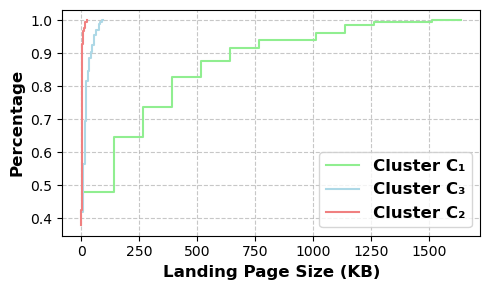

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_landing_page_size_cdf(df, page_size_col='Landing_Page_Size_In_KB', cluster_col='Majority Voting Label'):
    """
    Visualizes the cumulative distribution of landing page sizes (in KB) across different clusters
    using a Cumulative Distribution Function (CDF) plot, with consistent styling.

    Args:
        df (pd.DataFrame): DataFrame containing the data.
        page_size_col (str, optional): The name of the column containing the landing page sizes.
            Defaults to 'Landing_Page_Size_In_KB'.
        cluster_col (str, optional): The name of the column containing the cluster labels.
            Defaults to 'Majority Voting Label'.
    """
    # Check if the required columns exist
    if not all(col in df.columns for col in [page_size_col, cluster_col]):
        raise ValueError(f"DataFrame must contain columns '{page_size_col}' and '{cluster_col}'.")

    # Get unique cluster labels
    clusters = df[cluster_col].unique()

    # Define colors for up to 3 clusters
    colors = ['lightgreen', 'lightblue', 'lightcoral']
    labels = ['C₁', 'C₃', 'C₂']
    if len(clusters) > 3:
        print(f"Warning: More than 3 clusters detected. Only the first 3 colors and labels will be used. Clusters are: {clusters}")

    # Create the plot
    fig, ax = plt.subplots(figsize=(5, 3))  # Adjust figure size as needed.

    # Plot the CDF for each cluster
    for i, cluster in enumerate(clusters):
        subset = df[df[cluster_col] == cluster]
        sns.histplot(subset[page_size_col], cumulative=True, stat='density',
                     label=f'Cluster {labels[i]}', color=colors[i % len(colors)], # Changed label here
                     element='step', fill=False)

    # Set labels and title, using the specified font weight and size
    ax.set_xlabel('Landing Page Size (KB)', fontweight='bold', fontsize=12)
    ax.set_ylabel('Percentage', fontweight='bold', fontsize=12)
    # ax.set_title('Cumulative Distribution of Landing Page Size by Cluster', fontweight='bold', fontsize=14)

    # Add a legend with bold text
    legend = ax.legend(title='', fontsize=12)
    if legend:
        for text in legend.get_texts():
            text.set_fontweight('bold')
        if legend.get_title():
            legend.get_title().set_fontweight('bold')

    plt.grid(True, linestyle='--', alpha=0.7)  # Add grid for readability
    plt.tight_layout()  # Adjust layout to prevent labels from overlapping
    plt.show()



plot_landing_page_size_cdf(df_single_page)
# If your dataframe is named differently, change the name here.
# plot_landing_page_size_cdf(your_dataframe)


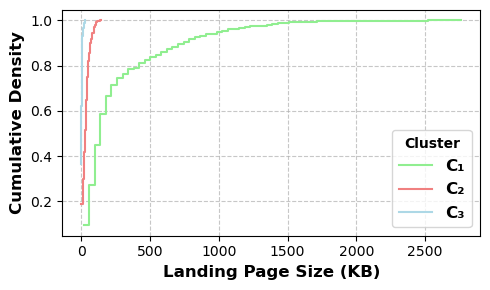

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_landing_page_size_cdf(df, page_size_col='Landing_Page_Size_In_KB', cluster_col='Majority Voting Label'):
    """
    Visualizes the cumulative distribution of landing page sizes (in KB) across different clusters
    using a Cumulative Distribution Function (CDF) plot, with consistent styling.

    Args:
        df (pd.DataFrame): DataFrame containing the data.
        page_size_col (str, optional): The name of the column containing the landing page sizes.
            Defaults to 'Landing_Page_Size_In_KB'.
        cluster_col (str, optional): The name of the column containing the cluster labels.
            Defaults to 'Majority Voting Label'.
    """
    # Check if the required columns exist
    if not all(col in df.columns for col in [page_size_col, cluster_col]):
        raise ValueError(f"DataFrame must contain columns '{page_size_col}' and '{cluster_col}'.")

    # Get unique cluster labels
    clusters = df[cluster_col].unique()

    # Define colors for up to 3 clusters
    colors = ['lightgreen', 'lightcoral', 'lightblue']
    labels = ['C₁', 'C₂', 'C₃']
    if len(clusters) > 3:
        print(f"Warning: More than 3 clusters detected. Only the first 3 colors and labels will be used. Clusters are: {clusters}")

    # Create the plot
    fig, ax = plt.subplots(figsize=(5, 3))  # Adjust figure size as needed.

    # Plot the CDF for each cluster
    for i, cluster in enumerate(clusters):
        subset = df[df[cluster_col] == cluster]
        sns.histplot(subset[page_size_col], cumulative=True, stat='density',
                     label=labels[i % len(labels)], color=colors[i % len(colors)],
                     element='step', fill=False)

    # Set labels and title, using the specified font weight and size
    ax.set_xlabel('Landing Page Size (KB)', fontweight='bold', fontsize=12)
    ax.set_ylabel('Cumulative Density', fontweight='bold', fontsize=12)
    # ax.set_title('Cumulative Distribution of Landing Page Size by Cluster', fontweight='bold', fontsize=14)

    # Add a legend with bold text
    legend = ax.legend(title='Cluster', fontsize=12)
    if legend:
        for text in legend.get_texts():
            text.set_fontweight('bold')
        if legend.get_title():
            legend.get_title().set_fontweight('bold')

    plt.grid(True, linestyle='--', alpha=0.7)  # Add grid for readability
    plt.tight_layout()  # Adjust layout to prevent labels from overlapping
    plt.show()




# Call the function with your DataFrame
plot_landing_page_size_cdf(df)
# If your dataframe is named differently, change the name here.
# plot_landing_page_size_cdf(your_dataframe)
